In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("benchmark_results.json", "r") as f:
    results = json.load(f)

In [3]:
results

{'MLPModular-20260328-004410': {'checkpoint_dir': '/n/holylfs06/LABS/olveczky_lab/Users/ewarnberg/vnl-experiments/checkpoints/MLPModular-20260328-004410',
  'step': 500019200,
  'n_actor_params': 3581000,
  'n_critic_params': 447499,
  'train': {'aggregate': {'n_clips': 673,
    'mean_episode_reward': 11230.99167745287,
    'mean_lifespan': 249.78454680534918,
    'mean_hand_L_pos_err_m': 0.005711093200384508,
    'mean_foot_L_pos_err_m': 0.010738831850662716,
    'mean_root_pos_err_m': 0.005690415813982},
   'by_label': {'FaceGroom': {'n_clips': 109,
     'mean_episode_reward': 11463.288757884175,
     'mean_lifespan': 250.0,
     'mean_hand_L_pos_err_m': 0.004004883121724727,
     'mean_foot_L_pos_err_m': 0.009071633911802681,
     'mean_root_pos_err_m': 0.004605489121878161},
    'FastWalk': {'n_clips': 152,
     'mean_episode_reward': 11027.33343827097,
     'mean_lifespan': 250.0,
     'mean_hand_L_pos_err_m': 0.007310206502504451,
     'mean_foot_L_pos_err_m': 0.01209536251783567

In [4]:
key_metrics = []
for k in results.keys():
    architecture = "MLP" if k.startswith("MLP") else "Modular"
    for dataset in ["train", "eval"]:
        key_metrics.append({
            "run_name": k,
            "dataset": dataset,
            "architecture": architecture,
            "n_actor_params": results[k]["n_actor_params"],
            **results[k][dataset]["aggregate"],
        })

/tmp/ipykernel_12617/663362162.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_12617/663362162.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_12617/663362162.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), frameon=False)
/tmp/ipykernel_12617/663362162.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.2, 0.15), fra

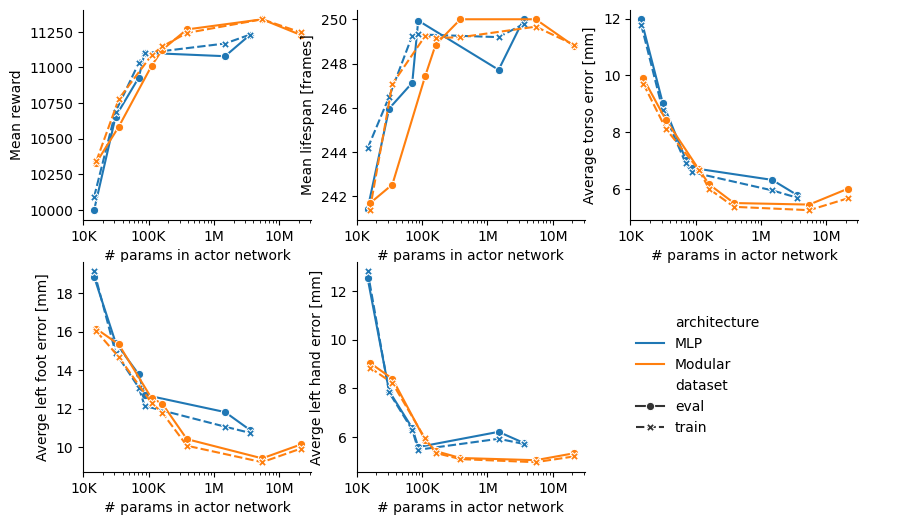

In [5]:
df = pd.DataFrame(key_metrics)
for c in df.columns:
    if c.endswith("_m"):
        df[c+"m"] = df[c]*1000 #m to mm conversion
metrics = {"mean_episode_reward": "Mean reward",
           "mean_lifespan": "Mean lifespan [frames]",
           "mean_root_pos_err_mm": "Average torso error [mm]",
           "mean_foot_L_pos_err_mm": "Averge left foot error [mm]",
           "mean_hand_L_pos_err_mm": "Averge left hand error [mm]"}
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
for ax, metric in zip(axs.flat, metrics.keys()):
    plt.sca(ax)
    legend = metric == "mean_hand_L_pos_err_mm"
    sns.lineplot(data=df, x="n_actor_params", y=metric, hue="architecture", style="dataset", markers=True, style_order=["eval", "train"], legend=legend)
    plt.legend(loc=(1.2, 0.15), frameon=False)
    plt.xscale('log')
    plt.xlabel("# params in actor network")
    plt.ylabel(metrics[metric])
    plt.xticks([1e4, 1e5, 1e6, 1e7], ["10K", "100K", "1M", "10M"])
    sns.despine()
axs.flat[-1].axis("off")
#plt.tight_layout()
plt.show()